# Titanic: исследовательский анализ

Изучены пропуски, распределения, выбросы и связь выживаемости с полом, классом и возрастом. Сохранены исходные графики; результаты обучения и команды запуска приведены в README.


In [2]:
%pip install pandas numpy matplotlib scikit-learn seaborn 


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import seaborn as sns

In [29]:
data = pd.read_csv("train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
data["Sex"] = data["Sex"].map({"male": 1, "female": 0})

In [6]:
data.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [8]:
corr = data.corr(numeric_only=True)

corr["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64

Больше всего пропусков в `Cabin`; возраст неизвестен примерно у пятой части пассажиров. Для исходного baseline исключаем `Name`, `Ticket` и `Cabin`. В последующих Classic ML экспериментах из имени извлекается `Title`. Далее сравним выживаемость по полу и классу.


<Axes: xlabel='Sex', ylabel='count'>

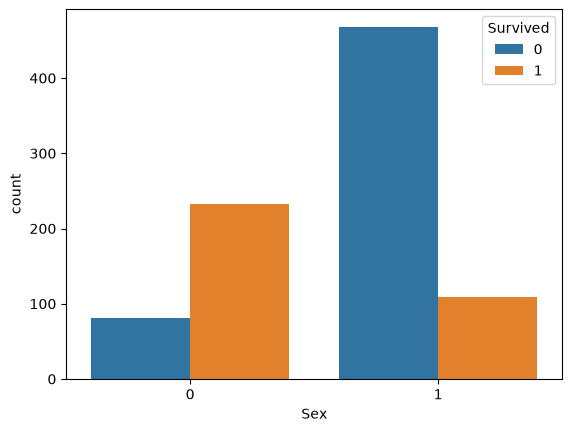

In [9]:
sns.countplot(data, x="Sex", hue="Survived")

<Axes: xlabel='Pclass', ylabel='count'>

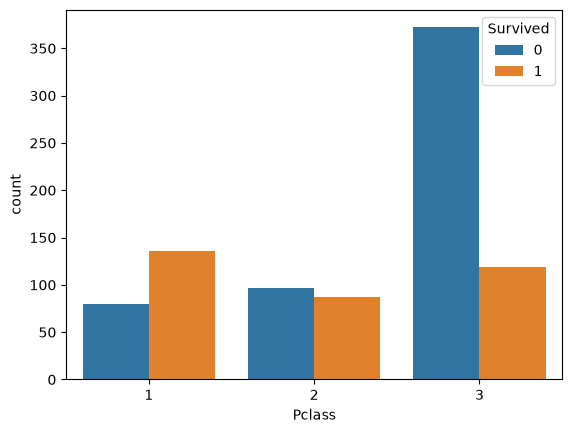

In [10]:
sns.countplot(data, x="Pclass", hue="Survived")

Женщин в выборке меньше, но доля выживших среди них выше. Пассажиров третьего класса больше всего; доля выживших выше в первом классе. Графики показывают связь признаков с исходом, но не устанавливают её причину.


<Axes: xlabel='Survived', ylabel='Fare'>

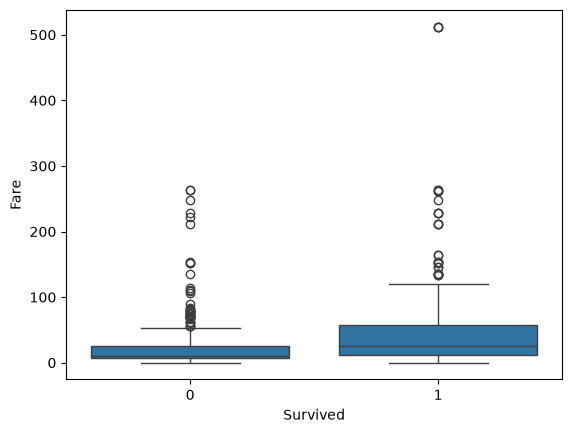

In [11]:
sns.boxplot(data=data, x="Survived", y="Fare")

<Axes: xlabel='Survived', ylabel='Age'>

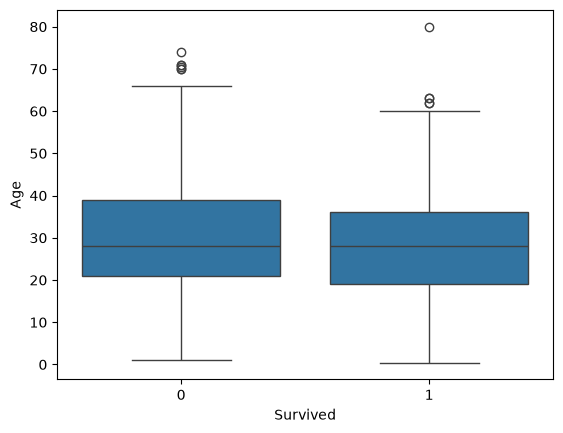

In [12]:
sns.boxplot(data=data, x="Survived", y="Age")

У выживших медианная стоимость билета выше. `Fare` содержит сильные выбросы и имеет правый хвост. По общему распределению возраста связь с исходом выражена слабее; её стоит рассматривать совместно с полом и классом.


<Axes: xlabel='Embarked', ylabel='count'>

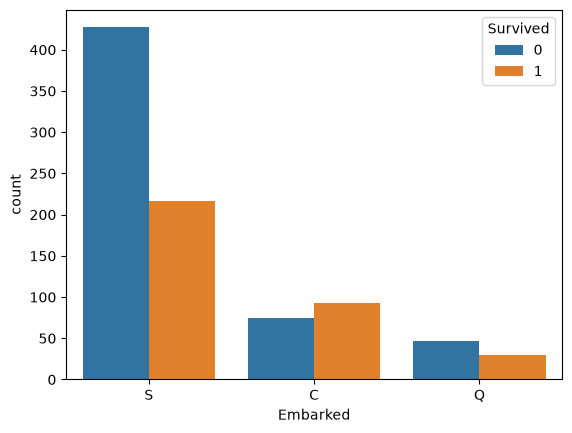

In [13]:
sns.countplot(data=data, x="Embarked", hue="Survived")

<Axes: xlabel='SibSp', ylabel='count'>

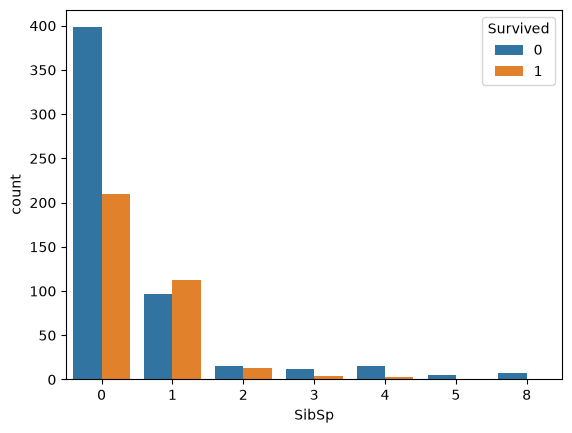

In [14]:
sns.countplot(data=data, x="SibSp", hue="Survived")

<Axes: xlabel='Parch', ylabel='count'>

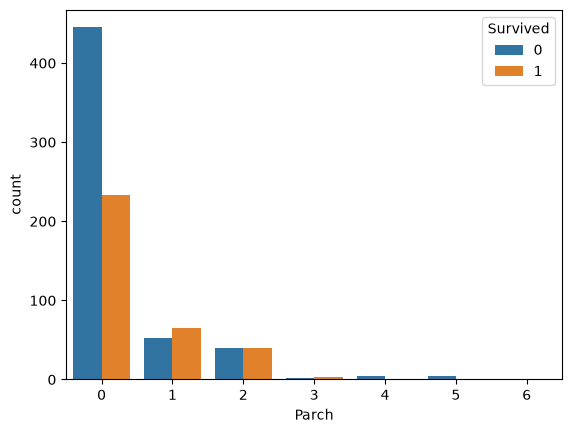

In [15]:
sns.countplot(data=data, x="Parch", hue="Survived")

В этих графиках связь `SibSp` и `Parch` с исходом слабее, чем у пола и класса. Это не доказывает бесполезность признаков: семейные комбинации проверялись отдельно в экспериментах.


<Axes: xlabel='CabinKnown', ylabel='Survived'>

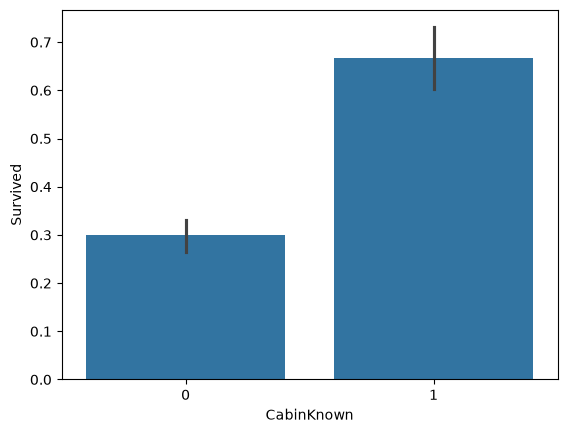

In [16]:
data["CabinKnown"] = data["Cabin"].notna().astype(int)

sns.barplot(data=data, x="CabinKnown", y="Survived")

<Axes: xlabel='Deck', ylabel='Survived'>

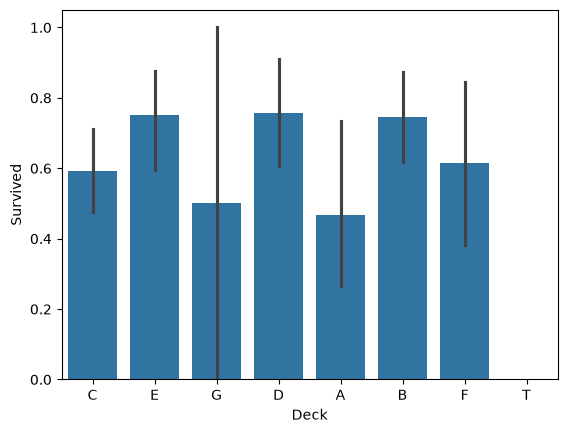

In [17]:
data["Deck"] = data["Cabin"].str[0]
sns.barplot(data=data, x="Deck", y="Survived")

Для `Cabin` много пропусков, поэтому выводы только по известным кабинам могут быть смещены. В использованном baseline колонка исключена. Наиболее заметные связи в EDA — пол, класс и стоимость билета.


<Axes: xlabel='Pclass', ylabel='Survived'>

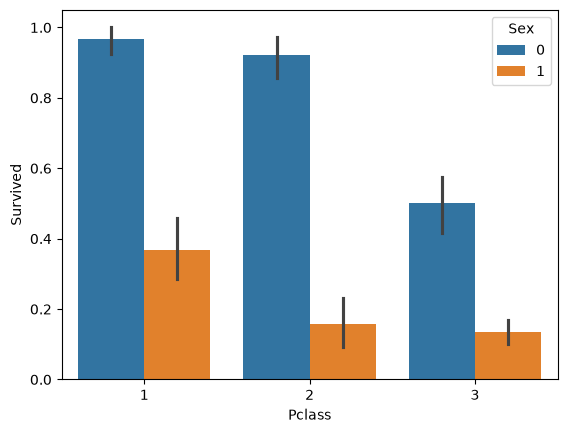

In [18]:
sns.barplot(data=data, x="Pclass", y="Survived", hue="Sex")

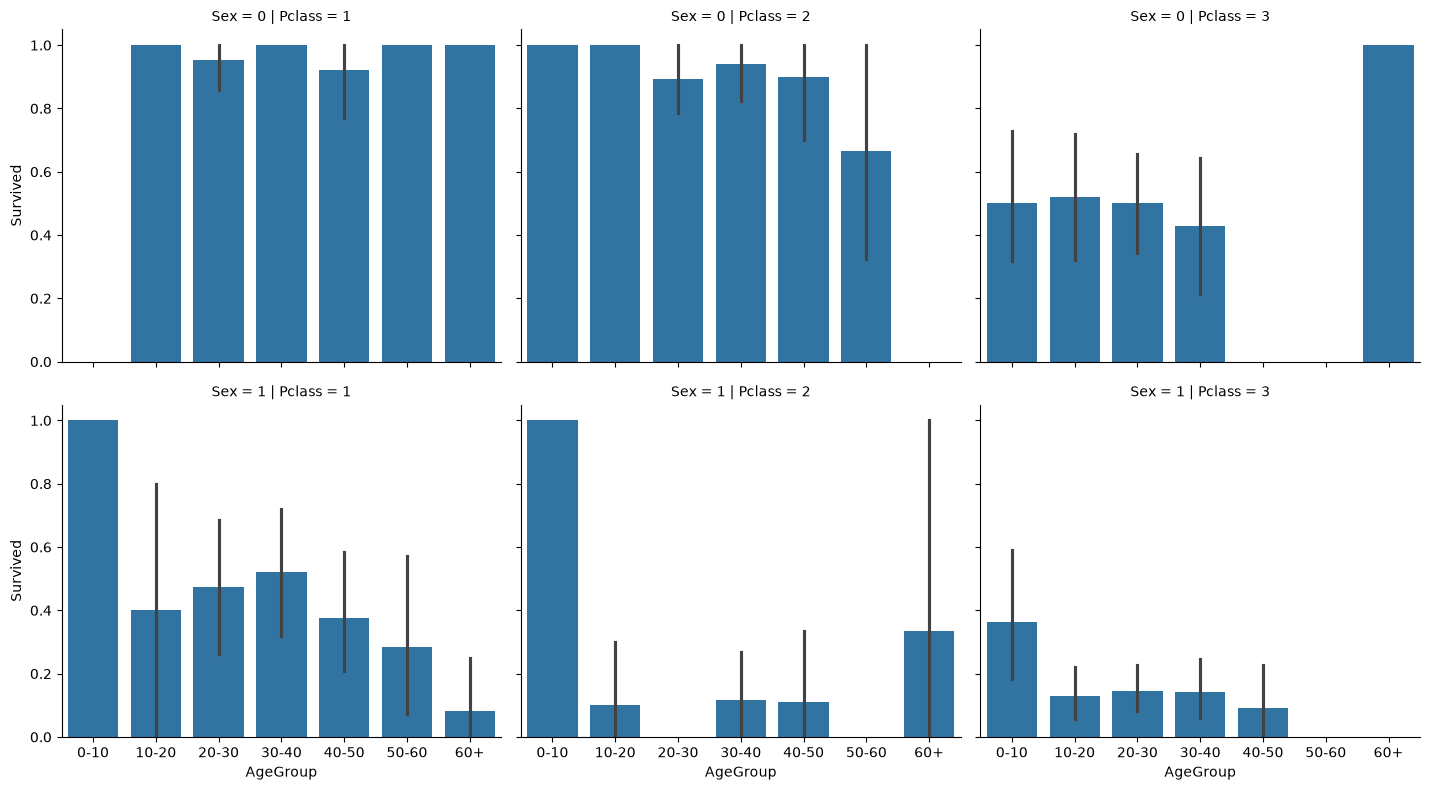

In [19]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[0, 10, 20, 30, 40, 50, 60, 100],
    labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60+"],
)

sns.catplot(
    data=data,
    x="AgeGroup",
    y="Survived",
    row="Sex",
    col="Pclass",
    kind="bar",
    height=4,
    aspect=1.2,
)

Во всех классах доля выживших среди женщин выше, чем среди мужчин. У детей-мужчин в первом и втором классах выживаемость визуально выше. В некоторых возрастных группах мало пассажиров: высокий процент выживших там не является устойчивым правилом. Для построения модели нужны валидация и проверка сочетаний признаков.


Также надо изучить аномальные объекты/выбросы

In [20]:
data[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [21]:
data.nlargest(10, "Age")[["Age", "Survived", "Pclass", "Sex"]]

,Age,Survived,Pclass,Sex
630,80.0,1,1,1
851,74.0,0,3,1
96,71.0,0,1,1
493,71.0,0,1,1
116,70.5,0,3,1
672,70.0,0,2,1
745,70.0,0,1,1
33,66.0,0,2,1
54,65.0,0,1,1
280,65.0,0,3,1


In [22]:
data.nlargest(10, "Fare")[["Fare", "Survived", "Pclass", "Sex"]]

,Fare,Survived,Pclass,Sex
258,512.3292,1,1,0
679,512.3292,1,1,1
737,512.3292,1,1,1
27,263.0000,0,1,1
88,263.0000,1,1,0
341,263.0000,1,1,0
438,263.0000,0,1,1
311,262.3750,1,1,0
742,262.3750,1,1,0
118,247.5208,0,1,1


Крайние значения `Age` выглядят реалистично. Большие значения `Fare` требуют внимания из-за сильной асимметрии, но сами по себе не доказывают ошибку данных. В финальном решении эти строки сохранены.
